# Concatenating neural datasets in deepSTRF

deepSTRF lets you concatenate two or more `NeuralDataset` instances along
**both** the stim and neuron axes, producing a single chimeric dataset
that pools recordings from different sources. This notebook walks
through the feature on CRCNS AA1 + AA2 — same species (zebra finch),
similar experimental preparations, but disjoint cohorts and stimulus
sets.

For the design rationale and the full API, see
[`dataset_concatenation.md`](../docs/_source/md/dataset_concatenation.md)
and [`data_paradigm.md`](../docs/_source/md/data_paradigm.md).

Two worked examples below: the single-species AA1 + AA2 case (most of the
notebook), and a cross-species AA1 + NS1 chimera (ferret A1 + zebra finch
Field L / MLd) at the end as the most distinctive use case.

## Setup


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from deepSTRF.datasets.audio.CRCNS_AA1_Dataset import CRCNS_AA1_Dataset
from deepSTRF.datasets.audio.CRCNS_AA2_Dataset import CRCNS_AA2_Dataset
from deepSTRF.utils.data import concat_neural_datasets, neural_collate

AA1_PATH = "../deepSTRF/datasets/audio/CRCNS_AA1/data/"
AA2_PATH = "../deepSTRF/datasets/audio/CRCNS_AA2/data/"
DT_MS = 5


## 1. Load the two source datasets

Both must share `dt_ms` and `n_mels` (audio's `F`). deepSTRF will assert
on a mismatch — see the **Compatibility** section below.


In [2]:
aa1 = CRCNS_AA1_Dataset(AA1_PATH, dt_ms=DT_MS)
aa2 = CRCNS_AA2_Dataset(AA2_PATH, dt_ms=DT_MS, smooth=False)

print(f"aa1: {aa1}")
print(f"aa2: {aa2}")
print(f"both have F = {aa1.F} mel-bands and dt = {aa1.dt} ms — concatenable.")


aa1: CRCNS_AA1_Dataset(N_neurons=100, selected=0, N_stims=30, dt_ms=5)
aa2: CRCNS_AA2_Dataset(N_neurons=494, selected=0, N_stims=117, dt_ms=5)
both have F = 32 mel-bands and dt = 5 ms — concatenable.


## 2. Concatenate

Two equivalent forms:


In [3]:
combined = concat_neural_datasets([aa1, aa2])
combined_alt = aa1 + aa2     # pairwise __add__ sugar; identical result

assert combined.N_neurons == combined_alt.N_neurons
assert combined.get_S() == combined_alt.get_S()

print(f"combined: {combined}")
print(f"  type     : {type(combined).__name__}   "
      f"# most-specific common ancestor (AA1 + AA2 -> AudioNeuralDataset)")
print(f"  N        : {aa1.N_neurons} + {aa2.N_neurons} = {combined.N_neurons}")
print(f"  S        : {aa1.get_S()} + {aa2.get_S()} = {combined.get_S()}")


combined: AudioNeuralDataset(N_neurons=594, selected=0, N_stims=147, dt_ms=5)
  type     : AudioNeuralDataset   # most-specific common ancestor (AA1 + AA2 -> AudioNeuralDataset)
  N        : 100 + 494 = 594
  S        : 30 + 117 = 147


## 3. The block-diagonal `nrn_masks`

Concatenation places each source dataset in its own `(S_i, N_i)` block on
the diagonal. The cross-blocks — stims from one source paired with
neurons from another — are filled with the canonical `(1, 1)` NaN
sentinel, so deepSTRF's existing missingness machinery (the `nrn_masks`
property derived on the fly from `responses`) handles them automatically.

The total number of "real data" pairs in the combined mask should equal
the sum of valid pairs in the sources — no double-counting, no leak
across the diagonal.


In [4]:
expected = int(aa1.nrn_masks.sum()) + int(aa2.nrn_masks.sum())
got = int(combined.nrn_masks.sum())
print(f"valid (stim, neuron) pairs in aa1: {int(aa1.nrn_masks.sum())}")
print(f"valid (stim, neuron) pairs in aa2: {int(aa2.nrn_masks.sum())}")
print(f"sum                              : {expected}")
print(f"valid pairs in combined          : {got}    "
      f"(matches: {got == expected})")


valid (stim, neuron) pairs in aa1: 2960


valid (stim, neuron) pairs in aa2: 18902
sum                              : 21862
valid pairs in combined          : 21862    (matches: True)


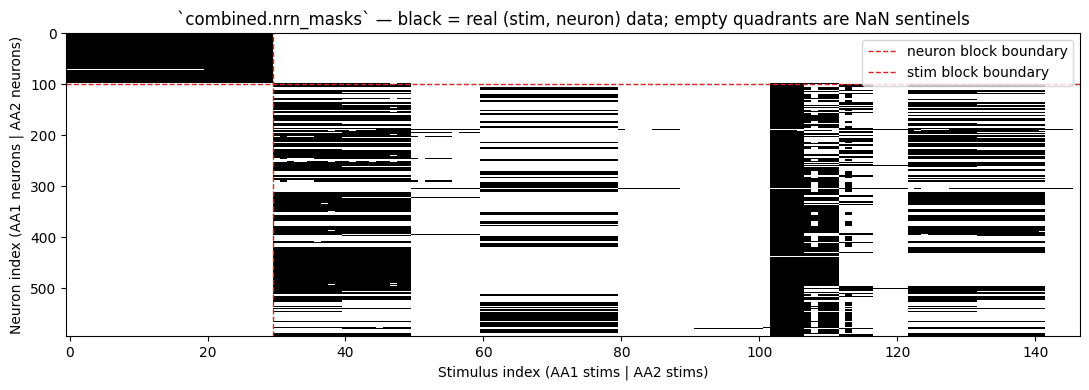

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.imshow(combined.nrn_masks.T.numpy(), aspect="auto", cmap="Greys",
          interpolation="nearest")
ax.axhline(aa1.N_neurons - 0.5, color="tab:red", lw=1, ls="--",
           label="neuron block boundary")
ax.axvline(aa1.get_S() - 0.5,  color="tab:red", lw=1, ls="--",
           label="stim block boundary")
ax.set_xlabel("Stimulus index (AA1 stims | AA2 stims)")
ax.set_ylabel("Neuron index (AA1 neurons | AA2 neurons)")
ax.set_title(f"`combined.nrn_masks` — black = real (stim, neuron) data; "
             f"empty quadrants are NaN sentinels")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


The two black quadrants are the AA1 and AA2 source blocks (preserving
each dataset's intra-source coverage pattern). The two empty quadrants
are the cross-blocks — where AA1 neurons are paired with AA2 stims and
vice versa, with NaN sentinels filling those entries.


## 4. Metadata flows through

Each source's `stim_meta` and `neuron_metadata` are concatenated in the
same order as the data, so `combined.neuron_metadata[42]` still returns
AA1's 42nd neuron's dict, and `combined.neuron_metadata[120]` returns
AA2's 20th (after the 100 AA1 neurons).

This means the neuron-selection helpers continue to work with no
adaptation:


In [6]:
# select all MLd neurons in the combined dataset — picks them up from
# BOTH sources (AA1 and AA2 both happen to use the "MLd"/"mld" label).
combined.select_pop_by_nrn_attr("area", "MLd")
print(f"MLd neurons selected from combined: {len(combined.I)}")

# AA2 uses lowercase 'mld' for its area label; we can union both:
mld_indices = [
    n for n, meta in enumerate(combined.neuron_metadata)
    if meta["area"].lower() == "mld"
]
combined.select_population(mld_indices)
print(f"MLd-or-mld neurons (case-insensitive): {len(combined.I)} "
      f"({100 * len(combined.I) / combined.N_neurons:.1f}% of pooled population)")


MLd neurons selected from combined: 50
MLd-or-mld neurons (case-insensitive): 193 (32.5% of pooled population)



## 4.5 Iteration follows the selection

This is where chimeric datasets really earn their keep. `len(combined)`
and `combined[i]` are both filtered by the current neuron selection — they
only expose stimuli for which at least one selected neuron has valid
response data. Selecting one source's neurons therefore hides the other
source's stimuli from iteration entirely, with no extra bookkeeping in
the training loop.

(See [`data_paradigm.md`](../docs/_source/md/data_paradigm.md) §8 for
the general rule across all `NeuralDataset` instances. The chimeric case
is just a particularly clean illustration.)


In [7]:

# default: every neuron selected -> every stim is iterable.
combined.select_population(list(range(combined.N_neurons)))
print(f"all neurons:        len(combined) = {len(combined):>3}    "
      f"(expect {aa1.get_S()} + {aa2.get_S()} = {aa1.get_S() + aa2.get_S()})")

# select only AA1's neurons -> AA2's stims disappear.
combined.select_population(list(range(aa1.N_neurons)))
print(f"only AA1's neurons: len(combined) = {len(combined):>3}    "
      f"(expect {aa1.get_S()})")
print(f"  combined[0] stim_meta  = {combined[0][3]}")
print(f"  combined[-1] stim_meta = {combined[-1][3]}    # last iterable")
try:
    combined[aa1.get_S()]
except IndexError as e:
    print(f"  combined[{aa1.get_S()}] raises IndexError — AA2 stim is hidden, not silently NaN")

# select only AA2's neurons -> AA1's stims disappear.
combined.select_population(list(range(aa1.N_neurons, combined.N_neurons)))
print(f"only AA2's neurons: len(combined) = {len(combined):>3}    "
      f"(expect {aa2.get_S()})")
print(f"  combined[0] stim_meta  = {combined[0][3]}    # first iterable is AA2's first stim")


all neurons:        len(combined) = 147    (expect 30 + 117 = 147)


only AA1's neurons: len(combined) =  30    (expect 30)


  combined[0] stim_meta  = {'name': '058767E725C83836F405A97FD7D1E751.wav', 'type': 'conspecific', 'sample_rate': 32000.0, 'n_samples': 62144, 'duration_s': 1.942}


  combined[-1] stim_meta = {'name': 'FDD2F383A22BCFA000DEBD48FAC0ADF0.wav', 'type': 'flatrip', 'sample_rate': 32000.0, 'n_samples': 64000, 'duration_s': 2.0}    # last iterable


  combined[30] raises IndexError — AA2 stim is hidden, not silently NaN


only AA2's neurons: len(combined) = 117    (expect 117)


  combined[0] stim_meta  = {'name': 'D54ABC42488F995C789F351A34316039.wav', 'type': 'conspecific', 'sample_rate': 32000.0, 'n_samples': 55105, 'duration_s': 1.72203125}    # first iterable is AA2's first stim



The training loop for a chimeric model that's only being supervised on
AA1's neurons therefore sees only AA1's stims — automatic. Same for
AA2. Use `select_pop_by_nrn_attr` to slice on metadata fields (e.g.
"all MLd neurons across both sources"), and the iterable space adapts
just as cleanly.


## 5. Iterating with `DataLoader`

The combined dataset is just a `NeuralDataset`, so `neural_collate`
batches it the same way it batches any single source. The `valid_mask`
returned by the collate already reflects the block-diagonal structure
of the cross-blocks — your loss code does not need any adaptation.


In [8]:
combined.select_population(list(range(min(combined.N_neurons, 32))))  # take 32 neurons for a small batch demo
loader = DataLoader(combined, batch_size=4, shuffle=False, collate_fn=neural_collate)

stims, responses, valid_mask, stim_metas = next(iter(loader))
print(f"stims shape       : {tuple(stims.shape)}")
print(f"responses shape   : {tuple(responses.shape)}")
print(f"valid_mask shape  : {tuple(valid_mask.shape)}    (B, N, R, T)")
print()
print(f"valid fraction in batch : {valid_mask.float().mean().item():.3f}")
print(f"stim_metas              : {stim_metas}")


stims shape       : (4, 1, 32, 460)
responses shape   : (4, 32, 15, 460)
valid_mask shape  : (4, 32, 15, 460)    (B, N, R, T)

valid fraction in batch : 0.576
stim_metas              : [{'name': '058767E725C83836F405A97FD7D1E751.wav', 'type': 'conspecific', 'sample_rate': 32000.0, 'n_samples': 62144, 'duration_s': 1.942}, {'name': '0A07B255BF830083B6726388CA8510BA.wav', 'type': 'conspecific', 'sample_rate': 32000.0, 'n_samples': 73557, 'duration_s': 2.29865625}, {'name': '1470489635DD93410408CE9F8FB2F7D9.wav', 'type': 'conspecific', 'sample_rate': 32000.0, 'n_samples': 69890, 'duration_s': 2.1840625}, {'name': '42FED9F3EF45A238202B050B06F91652.wav', 'type': 'conspecific', 'sample_rate': 32000.0, 'n_samples': 52761, 'duration_s': 1.64878125}]


## 6. What deepSTRF refuses to concatenate

deepSTRF rejects mismatches that would silently produce wrong results.
You'd see an `AssertionError` from the relevant `_concat_check_compat`
hook. A couple of examples:


In [9]:
# dt mismatch -> rejected
aa2_finer_bin = CRCNS_AA2_Dataset(AA2_PATH, dt_ms=1, smooth=False)
try:
    combined = aa1 + aa2_finer_bin    # aa1 is dt=5, aa2_finer_bin is dt=1
except AssertionError as e:
    print(f"AssertionError (expected): {e}")


AssertionError (expected): dt mismatch: 5 vs 1. Resample responses to a common bin width before concatenating.


In [10]:
# F mismatch -> rejected
aa2_more_mels = CRCNS_AA2_Dataset(AA2_PATH, dt_ms=DT_MS, n_mels=64, smooth=False)
try:
    combined = aa1 + aa2_more_mels    # aa1 has F=32, aa2_more_mels has F=64
except AssertionError as e:
    print(f"AssertionError (expected): {e}")


AssertionError (expected): F mismatch: 32 vs 64. Re-instantiate with matching n_mels.


## 7. Across species: pooling AA1 (zebra finch) + NS1 (ferret)

The block-diagonal layout shines when sources come from different species,
labs, or stimulus banks. Since `aa1` and `ns1` have totally disjoint stim sets,
neurons, and recording protocols, every cross-block entry is a `(1, 1)` NaN
sentinel — there's no risk of accidental aliasing — and the resulting
chimeric dataset is something a single model can be fit to via the
`area`-filtered selection.

The only real requirement for cross-species concat: matching `dt_ms` and
`n_mels`. NS1's stimulus tensor is precomputed at `dt=5ms`, `F=34`, so we
load AA1 with the same parameters here.

AudioNeuralDataset(N_neurons=219, selected=0, N_stims=50, dt_ms=5)
  area=A1     -> 119 ferret neurons
  area=Field_L -> 50 zebra-finch neurons
  area=MLd     -> 50 zebra-finch neurons


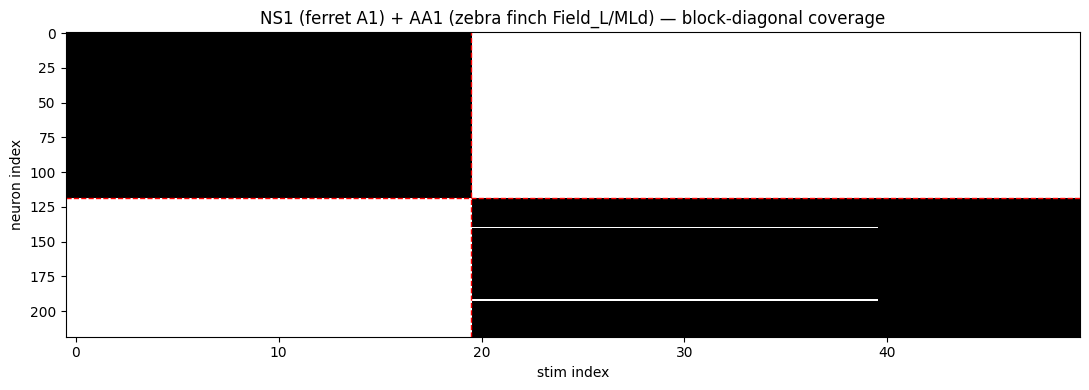

In [11]:
from deepSTRF.datasets.audio.NS1_DRC_Dataset import NS1_Dataset

NS1_PATH = '../deepSTRF/datasets/audio/NS1_DRC/data'

ns1 = NS1_Dataset(NS1_PATH, dt_ms=5)            # ferret A1, 119 neurons, 20 nat stims
aa1_34 = CRCNS_AA1_Dataset(AA1_PATH, dt_ms=5,
                           n_mels=34)            # match NS1's F=34
chimera = ns1 + aa1_34
print(chimera)
print(f"  area=A1     -> {len(chimera.select_pop_by_nrn_attr('area', 'A1'))} ferret neurons")
chimera.I = []
print(f"  area=Field_L -> {len(chimera.select_pop_by_nrn_attr('area', 'Field_L'))} zebra-finch neurons")
chimera.I = []
print(f"  area=MLd     -> {len(chimera.select_pop_by_nrn_attr('area', 'MLd'))} zebra-finch neurons")

# block-diagonal mask: NS1 covers stims 0..19 / neurons 0..118; AA1 covers stims 20..49 / neurons 119..218
fig, ax = plt.subplots(figsize=(11, 4))
ax.imshow(chimera.nrn_masks.T.numpy(), aspect='auto', cmap='gray_r', interpolation='nearest')
ax.axhline(ns1.N_neurons - 0.5, color='red', linestyle='--', linewidth=1)
ax.axvline(ns1.get_S() - 0.5,    color='red', linestyle='--', linewidth=1)
ax.set_xlabel('stim index')
ax.set_ylabel('neuron index')
ax.set_title('NS1 (ferret A1) + AA1 (zebra finch Field_L/MLd) — block-diagonal coverage')
plt.tight_layout()
plt.show()

## Recap

- `concat_neural_datasets([a, b, ...])` (or `a + b`) returns a single
  `NeuralDataset` whose stim and neuron axes are the unions of the
  inputs', with cross-block entries filled by NaN sentinels.
- The result's `nrn_masks` derives the block-diagonal coverage
  automatically from those sentinels — no extra bookkeeping.
- The combined dataset is a drop-in replacement for any of its
  source datasets in `DataLoader`, `neural_collate`, `select_*`, etc.
- deepSTRF rejects `dt_ms` and `F` (or `(H, W)`) mismatches at concat
  time — no silent resampling.

> Cross-species concatenation example (AA1 + NS1) will land here once
> NS1 is modernized to the new base API.
